## BTSP on a linear track

* Linear track, single direction
* CA3: 8 preset place fields
* CA1: 
  * Hebbian learning + BTSP learning at targeted neurons
  * BTSP learning: long-tailed (pre) Hebbian learning with a high output firing rate considered (occurs in one trajectory only)
  * (1) 1 cell, receives BTSP signal at a reward location
  * (2) 4 cells, with 2 receiving BTSP signals (near reward and start, respectively) 

Evaluate resulting CA1 neuron place field properties

In [1]:
import copy
from pathlib import Path
import sys
import warnings

from matplotlib import pyplot as plt
import numpy as np
import ratinabox

add_paths = [str(Path(".."))]
for add_path in add_paths:
    if add_path not in sys.path:
        sys.path.append(add_path)

from predhpc import agent, neurons, run_manager, plot_util, util

In [2]:
plot_util.stylize_plots_for_notebook()
ratinabox.autosave_plots = False
ratinabox.figure_directory = "figures"

In [3]:
warnings.filterwarnings(
    "ignore", message="solid 1D boundary", category=UserWarning
)
warnings.filterwarnings(
    "ignore", message="invalid value encountered", 
    category=RuntimeWarning
)

## Define some functions

In [4]:
def learn(env_params, agent_params, CA3_PC_params, CA1_params, 
          num_rewards=200, max_num_steps=5000, use_Hebbian=False, 
          btsp_after_num_target_reaches=5, two_compartment=False):
    
    print_vals = {
        "Agent dt": agent_params["dt"],
        "# CA3 PCs": CA3_PC_params["n"], 
        "# CA1s": CA1_params["n"], 
        "CA1 init at 0": CA1_params["init_weights_zero"], 
        "CA1 init scale": CA1_params["w_init_scale"], 
        "CA1 BTSP tau": CA1_params["btsp_filter_tau"], 
        "# rewards": num_rewards, 
        "Max # steps": max_num_steps, 
        "Hebbian learning": use_Hebbian, 
        "BTSP occurs after X number of target reaches": btsp_after_num_target_reaches,
        "Two-compartment": two_compartment,
    }
    print_vals = [
        f"{name:16}: {value}" for name, value in print_vals.items()
    ]
    print("{}\n".format('\n'.join(print_vals)))
    
    Env, Ag, CA3_PCs, CA1s = run_manager.learn_1D_btsp(
        env_params,
        agent_params,
        CA3_PC_params,
        CA1_params,
        num_rewards=num_rewards,
        max_num_steps=max_num_steps,
        use_Hebbian=use_Hebbian,
        btsp_after_num_target_reaches=btsp_after_num_target_reaches,
        two_compartment=two_compartment,
    )
    
    return Env, Ag, CA3_PCs, CA1s

## Reload

In [5]:
import importlib
importlib.reload(agent)
importlib.reload(neurons)
importlib.reload(run_manager)
importlib.reload(plot_util)
importlib.reload(util);

## Only 1 CA1 neuron

In [6]:
NUM_REWARDS = 8
MAX_NUM_STEPS = 5000
USE_HEBBIAN = False

CA1_params = {
    "n": 1,
    "init_weights_zero": True,
    "w_init_scale": 0.1, # set fairly small
    "btsp_filter_tau": run_manager.AGENT_PARAMS_1D["dt"] * 5,
    "btsp_fr": 30,
    "lr": 5e-5,
    "apply_Ojas_rule": True,
}

CA1_params_one = copy.copy(run_manager.CA1_PARAMS_1D)
CA1_params_one.update(CA1_params)

Agent dt        : 0.02
# CA3 PCs       : 16
# CA1s          : 1
CA1 init at 0   : True
CA1 init scale  : 0.1
CA1 BTSP tau    : 0.1
# rewards       : 8
Max # steps     : 5000
Hebbian learning: False
BTSP occurs after X number of target reaches: 4
Two-compartment : False



 12%|████▋                                  | 593/5000 [00:00<00:07, 603.48it/s]


Trajectory lengths (9) to date: 1.32 +/- 0.44 sec each
Trajectory lengths (9) to date: 66.00 +/- 21.86 steps each


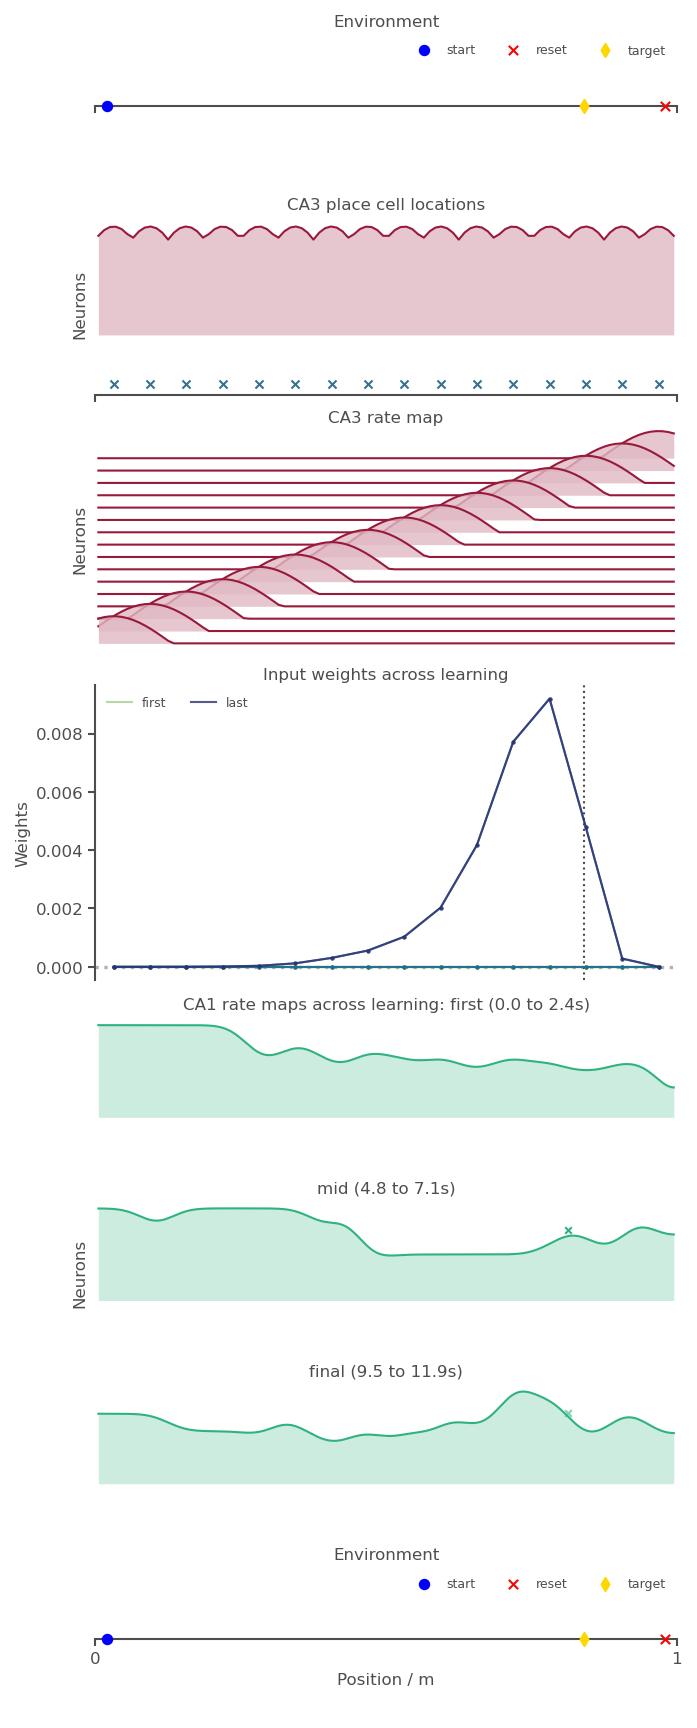

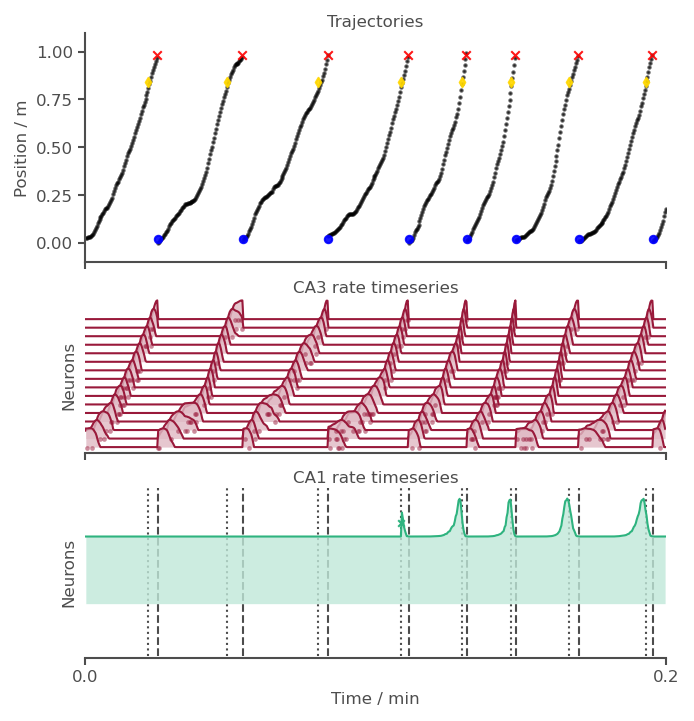

In [7]:
Env, Ag, CA3_PCs, CA1s = learn(
    run_manager.ENV_PARAMS_1D, 
    run_manager.AGENT_PARAMS_1D, 
    run_manager.CA3_PC_PARAMS_1D, 
    CA1_params_one, 
    num_rewards=NUM_REWARDS, 
    max_num_steps=MAX_NUM_STEPS,
    use_Hebbian=USE_HEBBIAN,
    btsp_after_num_target_reaches=4,
    two_compartment=False,
)

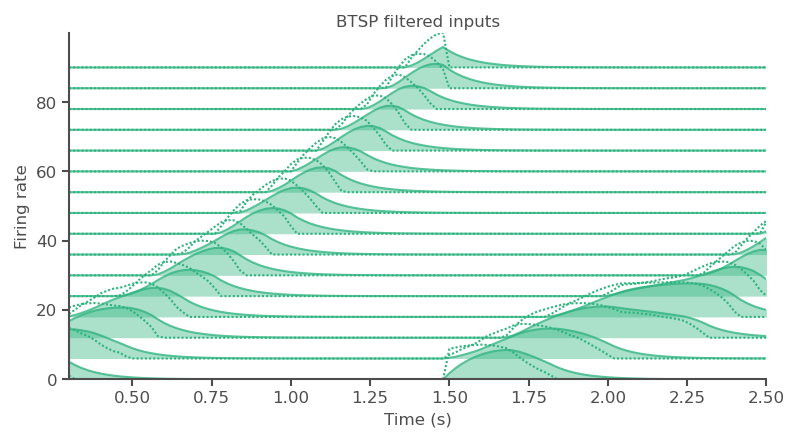

In [8]:
CA1s.plot_filtered_for_btsp("CA3_PCs", t_start=0.3, t_end=2.5);

## Multiple CA1 neurons

In [9]:
NUM_REWARDS = 16
MAX_NUM_STEPS = 5000
USE_HEBBIAN = True

CA1_params = {
    "n": 4,
    "init_weights_zero": True,
    "w_init_scale": 0.1, # set fairly small
    "btsp_filter_tau": run_manager.AGENT_PARAMS_1D["dt"] * 5,
    "btsp_fr": 50,
    "lr": 1e-4,
    "apply_Ojas_rule": True,
}

CA1_params_mult = copy.copy(run_manager.CA1_PARAMS_1D)
CA1_params_mult.update(CA1_params)

Agent dt        : 0.02
# CA3 PCs       : 16
# CA1s          : 4
CA1 init at 0   : True
CA1 init scale  : 0.1
CA1 BTSP tau    : 0.1
# rewards       : 16
Max # steps     : 5000
Hebbian learning: True
BTSP occurs after X number of target reaches: 5
Two-compartment : False



 23%|████████▉                             | 1171/5000 [00:02<00:07, 514.15it/s]


Trajectory lengths (17) to date: 1.38 +/- 0.51 sec each
Trajectory lengths (17) to date: 68.94 +/- 25.34 steps each


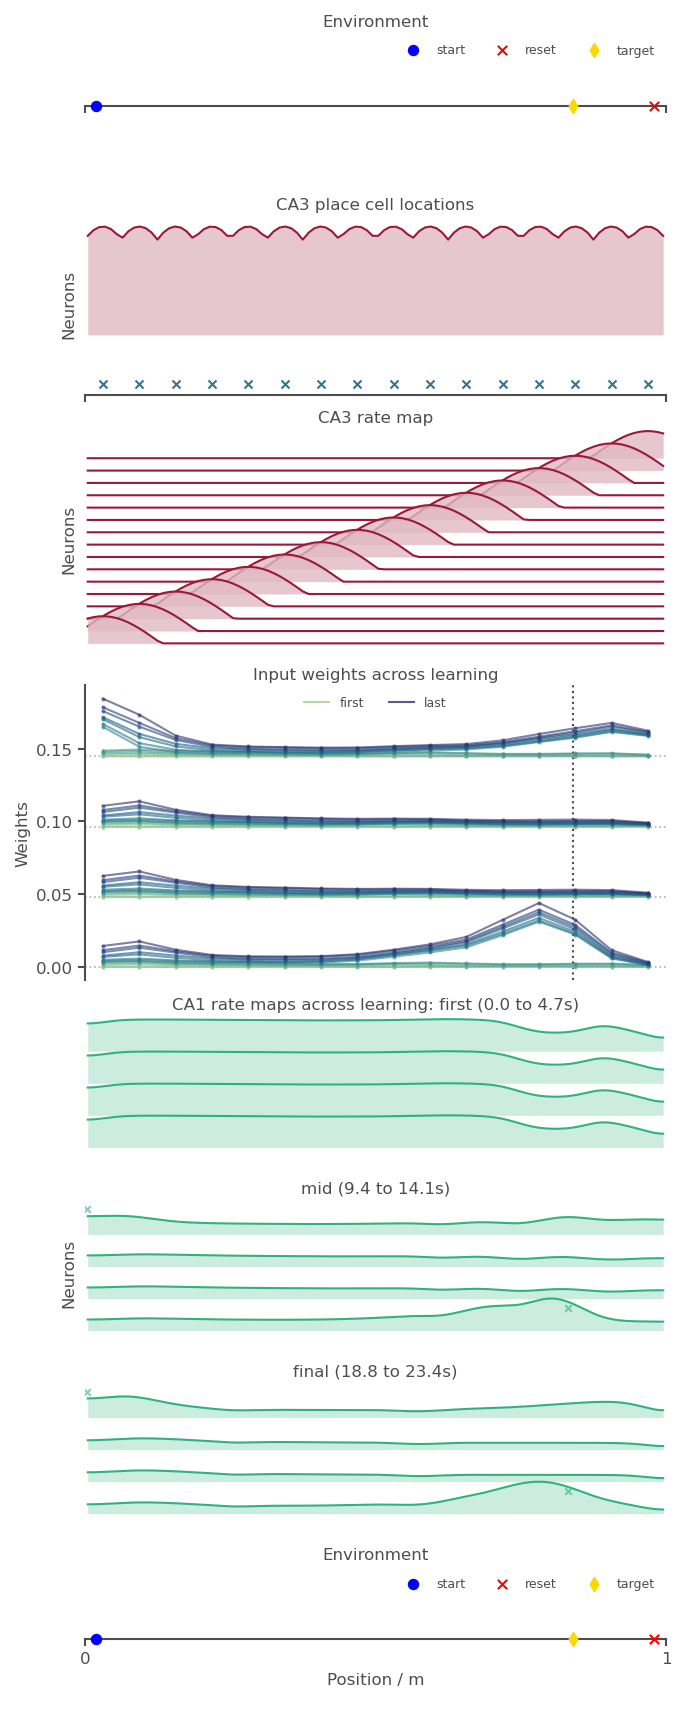

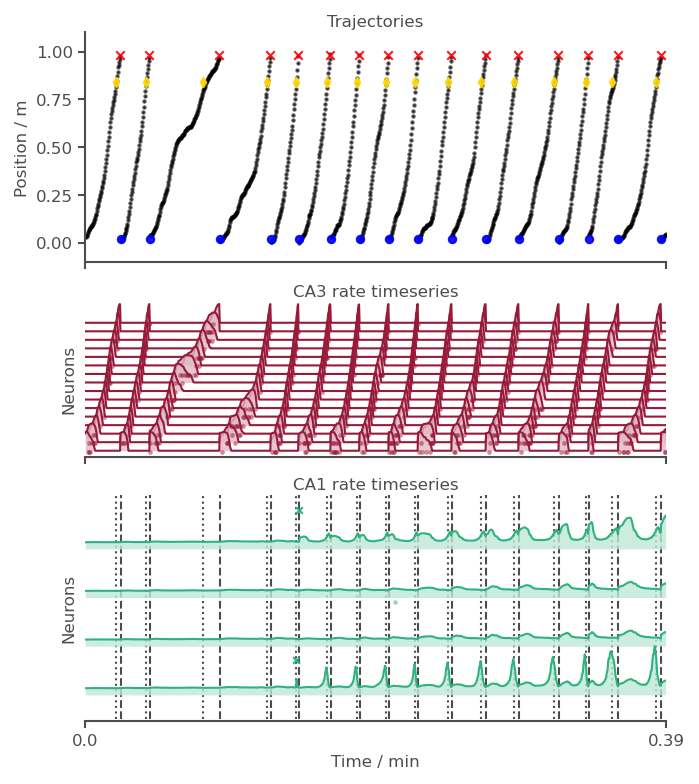

In [10]:
Env, Ag, CA3_PCs, CA1s = learn(
    run_manager.ENV_PARAMS_1D, 
    run_manager.AGENT_PARAMS_1D, 
    run_manager.CA3_PC_PARAMS_1D, 
    CA1_params_mult,
    num_rewards=NUM_REWARDS, 
    max_num_steps=MAX_NUM_STEPS,
    use_Hebbian=USE_HEBBIAN,
    btsp_after_num_target_reaches=5,
    two_compartment=False,
)

## BTSP filtered inputs

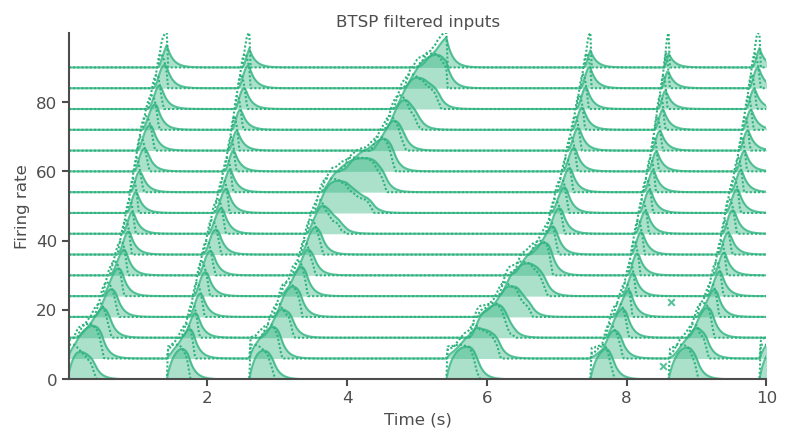

In [11]:
CA1s.plot_filtered_for_btsp("CA3_PCs", t_start=0, t_end=10);

## BTSP independent

In [ ]:
from ratinabox import Environment, PlaceCells

import importlib
importlib.reload(neurons.learning_neurons)
importlib.reload(run_manager)
importlib.reload(plot_util)
importlib.reload(agent)

from tqdm import tqdm

In [ ]:
env_params = {
    "boundary_conditions": "periodic", # to avoid receptor binding discontinuity
}

env_params_one = copy.copy(run_manager.ENV_PARAMS_1D)
env_params_one.update(env_params)

CA1_params = {
    "n": 1,
    "init_weights_zero": False,
    "w_init_scale": 0.2, # set fairly small
    "btsp_filter_tau": run_manager.AGENT_PARAMS_1D["dt"] * 5,
    "btsp_fr": 30,
    "lr": 1e-4,
    "apply_Ojas_rule": True,
    "btsp_single": True,
}

CA1_params_one = copy.copy(run_manager.CA1_PARAMS_1D)
CA1_params_one.update(CA1_params)

In [ ]:
Env = Environment(params=env_params_one)

Ag = agent.ResetableAgent(Env, params=run_manager.AGENT_PARAMS_1D)
CA3_PCs = PlaceCells(Ag, params=run_manager.CA3_PC_PARAMS_1D)

CA1_params = copy.copy(CA1_params)
CA1_params["input_layers"] = [CA3_PCs]
CA1s = neurons.learning_neurons.NMDALayer(Ag, params=CA1_params)
CA1s.set_learn()
CA1s.set_btsp_learn()

for i in tqdm(range(500)):
    Ag.update()
    CA3_PCs.update()
    CA1s.update()

run_manager.plot_1D_env_info(Ag, CA3_PCs, CA1s)
run_manager.plot_1D_time_info(Ag, CA3_PCs, CA1s);

In [ ]:
fig, axes = CA1s.NMDACurrent.plot_timeseries(datatypes="all")

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=[6, 2], sharey=True)
CA1s.NMDACurrent.plot_function("binding", max_fr=30, fig=fig, ax=ax[0])
CA1s.NMDACurrent.plot_function("activation", fig=fig, ax=ax[1])
ax[1].set_ylabel("");

## BTSP 2-compartment independent

In [ ]:
from ratinabox import Environment, PlaceCells

import importlib
importlib.reload(neurons.learning_neurons)
importlib.reload(neurons.two_comp_neurons)
importlib.reload(run_manager)
importlib.reload(plot_util)
importlib.reload(agent)

from tqdm import tqdm

In [ ]:
env_params = {
    "boundary_conditions": "periodic", # to avoid receptor binding discontinuity
}

env_params_one = copy.copy(run_manager.ENV_PARAMS_1D)
env_params_one.update(env_params)

CA1_params = {
    "n": 3,
    "dend_init_weights_zero": False,
    "soma_init_weights_zero": False,
    "dend_w_init_loc": 0.3,
    "soma_w_init_loc": 0.02,
    "dend_w_init_scale": 0.2,
    "soma_w_init_scale": 0,
    "btsp_filter_tau": run_manager.AGENT_PARAMS_1D["dt"] * 40,
    "btsp_fr": 30,
    "lr": 1e-4,
    "apply_Ojas_rule": False,
    "normalize_weights": False,
    "inhibit_weight": 2,
    "btsp_single": False,
    "soma_color": "#3D3D79",
    "dend_color": "#8787C9",
}

CA1_params_one = copy.copy(run_manager.CA1_TWO_COMP_PARAMS)
CA1_params_one.update(CA1_params)

In [ ]:
Env = Environment(params=env_params_one)

agent_params = copy.deepcopy(run_manager.AGENT_PARAMS_1D)
agent_params["target_position"] = run_manager.SCALE - run_manager.DT * 16,
Ag = agent.ResetableAgent(Env, params=agent_params)
# add objects directly
Env.objects = {"objects": np.asarray(Ag.target_position).reshape(1, 1), "object_types": np.asarray([0])}

ECs = neurons.object_neurons.ObjectCells(Ag, params=run_manager.EC_PARAMS_1D)
CA3_PCs = PlaceCells(Ag, params=run_manager.CA3_PC_PARAMS_1D)

CA1_params = copy.copy(CA1_params)
CA1_params["dend_input_layers"] = [ECs]
CA1_params["soma_input_layers"] = [CA3_PCs]
CA1s = neurons.two_comp_neurons.TwoCompLayer(Ag, params=CA1_params)
CA1s.set_learn(soma=False, dend=False, inhibit=False)
CA1s.set_btsp_learn(soma=True, dend=False)

for i in tqdm(range(500)):
    Ag.update()
    ECs.update()
    CA3_PCs.update()
    CA1s.update()

In [ ]:
env_figs, env_axes = run_manager.plot_1D_env_info(Ag, CA3_PCs, CA1s);
time_figs, time_axes = run_manager.plot_1D_time_info(Ag, CA3_PCs, CA1s);

In [ ]:
fig, ax = plt.subplots(figsize=[6, 8])
CA1s.plot_rate_map(fig=fig, ax=ax, t_start=-10, method="history", overlap=0.8);

In [ ]:
CA1s.SomaCompartment.plot_filtered_for_btsp("CA3_PCs");

In [ ]:
CA1s.DendriteCompartment.inputs